In [ ]:
# Decision tree vs Random forests example code 
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=10, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt.predict(X_test)))
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

Decision Tree Accuracy: 0.84
Random Forest Accuracy: 0.88


Accuracy: 0.9040
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       129
           1       0.87      0.94      0.90       121

    accuracy                           0.90       250
   macro avg       0.91      0.91      0.90       250
weighted avg       0.91      0.90      0.90       250



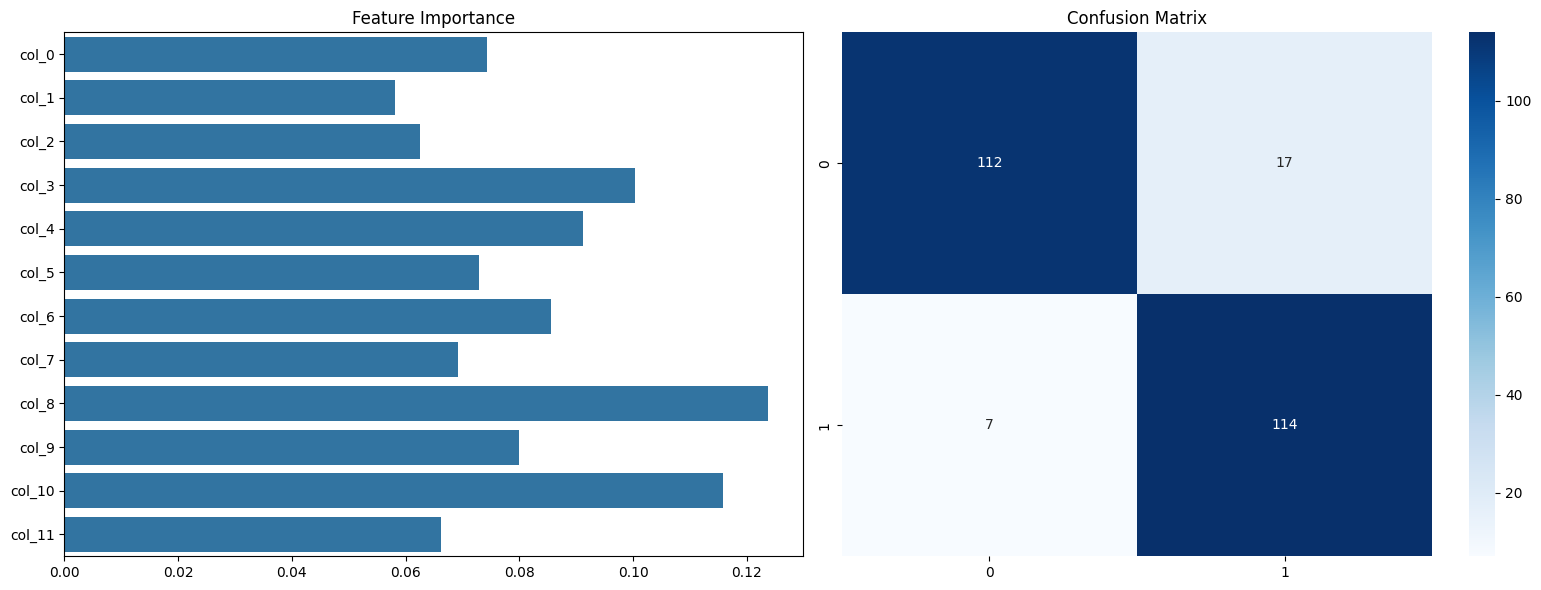

In [5]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X, y = make_classification(n_samples=1000, n_features=12, n_informative=8, n_redundant=4, random_state=42)
df = pl.DataFrame(X).with_columns(pl.Series("target", y))
feature_cols = [f"col_{i}" for i in range(12)]
df.columns = feature_cols + ["target"]

X_train, X_test, y_train, y_test = train_test_split(
    df.select(feature_cols).to_numpy(), 
    df.select("target").to_numpy().ravel(), 
    test_size=0.25, 
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    min_samples_split=5, 
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

importances = rf.feature_importances_
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=importances, y=feature_cols, ax=axes[0])
axes[0].set_title("Feature Importance")

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()